In [1]:
!pip install pyspark

In [2]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("FoodRecommendationSystem").getOrCreate() ###Create Spark Session

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
#Initialize Spark Session & Load Interaction Data
df = (
    spark.read.format("csv")
    .option("header", "true")
    .option("inferSchema", "true")
    .option("multiLine", "true")
    .option("escape", '"')
    .load("/content/drive/MyDrive/RAW_interactions.csv")
)

In [5]:
# Verify loaded record count and schema
print(f"Total records loaded: {df.count()}")
df.show(10)
df.printSchema()

Total records loaded: 1132367
+----------+---------+----------+------+--------------------+
|   user_id|recipe_id|      date|rating|              review|
+----------+---------+----------+------+--------------------+
|     38094|    40893|2003-02-17|     4|Great with a sala...|
|   1293707|    40893|2011-12-21|     5|So simple, so del...|
|      8937|    44394|2002-12-01|     4|This worked very ...|
|    126440|    85009|2010-02-27|     5|I made the Mexica...|
|     57222|    85009|2011-10-01|     5|Made the cheddar ...|
|     52282|   120345|2005-05-21|     4|very very sweet. ...|
|    124416|   120345|2011-08-06|     0|Just an observati...|
|2000192946|   120345|2015-05-10|     2|This recipe was O...|
|     76535|   134728|2005-09-02|     4|          Very good!|
|    273745|   134728|2005-12-22|     5|Better than the r...|
+----------+---------+----------+------+--------------------+
only showing top 10 rows
root
 |-- user_id: integer (nullable = true)
 |-- recipe_id: integer (nullabl

In [6]:
from pyspark.sql.functions import col

# Type Casting: Strings to Numeric Types
df_clean = df.select(
    col("user_id").cast("integer"),
    col("recipe_id").cast("integer"),
    col("rating").cast("float"),
).dropna()

#  verify Schema
df_clean.printSchema()

root
 |-- user_id: integer (nullable = true)
 |-- recipe_id: integer (nullable = true)
 |-- rating: float (nullable = true)



In [7]:
# Read the raw recipes dataset containing recipe titles
recipes_df = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load("/content/drive/MyDrive/RAW_recipes.csv")

In [8]:
# Extract essential columns and rename 'id' to 'recipe_id' for joining
recipe_names = recipes_df.select("id", "name").withColumnRenamed("id", "recipe_id")

In [9]:
# Merge interactions with recipe names using a left join
df_with_names = df_clean.join(recipe_names, on="recipe_id", how="left")

In [10]:
# Display the first 5 records of the joined DataFrame
from pyspark.sql.functions import col, expr

# Re-create recipe_names with robust type casting for recipe_id
recipe_names_corrected = recipes_df.select(
    expr("try_cast(id as int) as recipe_id"), # Cast 'id' to integer, handling malformed data
    col("name")
).dropna(subset=["recipe_id"]) # Drop rows where recipe_id became null due to try_cast failure

# Re-merge interactions with corrected recipe names using a left join
df_with_names_corrected = df_clean.join(recipe_names_corrected, on="recipe_id", how="left")

# Display the first 5 records of the joined DataFrame
df_with_names_corrected.show(5)

+---------+-------+------+--------------------+
|recipe_id|user_id|rating|                name|
+---------+-------+------+--------------------+
|    40893|  38094|   4.0|white bean   gree...|
|    40893|1293707|   5.0|white bean   gree...|
|   120345|  52282|   4.0| sugared raspberries|
|    44394|   8937|   4.0|devilicious cooki...|
|    85009| 126440|   5.0|baked potato topp...|
+---------+-------+------+--------------------+
only showing top 5 rows


In [11]:
df

DataFrame[user_id: int, recipe_id: int, date: date, rating: int, review: string]

In [12]:
df_with_names

DataFrame[recipe_id: int, user_id: int, rating: float, name: string]

###Part A

####Data Cleaning and PreProcessing

In [13]:
from pyspark.sql.functions import col, count, when, split, explode, desc, trim, lower, avg, round

In [14]:
from pyspark.sql.functions import col, count, when, expr

# cols_to_keep is already defined from a previous cell in the session.
# Re-create df_clean using the corrected joined DataFrame, df_with_names_corrected.
cols_to_keep = ["user_id", "recipe_id", "name", "rating"] # Ensure cols_to_keep is defined if not globally available
df_clean = df_with_names_corrected.select(*cols_to_keep)

# Apply cleaning step for 'name' column (from ln8k-iLOhNcn)
df_clean = df_clean.dropna(subset=["name"])

# Apply robust type casting using try_cast for all numeric columns.
# This converts any malformed strings to nulls, preventing NumberFormatException.
df_clean = df_clean.withColumn("user_id", expr("try_cast(user_id as int)")) \
                   .withColumn("recipe_id", expr("try_cast(recipe_id as int)")) \
                   .withColumn("rating", expr("try_cast(rating as float)"))

# Fill nulls (including those created by try_cast) with appropriate default values (from CA6thWWihRtU).
df_clean = df_clean.fillna({
    "user_id": 0,
    "recipe_id": 0,
    "rating": 0.0,
    "name": "Unknown Recipe"
})

print("Data cleaning complete. Verification of nulls:")
df_clean.select(
    [count(when(col(c).isNull(), c)).alias(c) for c in df_clean.columns]
).show()

Data cleaning complete. Verification of nulls:
+-------+---------+----+------+
|user_id|recipe_id|name|rating|
+-------+---------+----+------+
|      0|        0|   0|     0|
+-------+---------+----+------+



####Exploratory Data Analysis and Visualization

Top Recipe Categories/Tags by Average Rating:
+--------------------+----------+------------+
|      tag_individual|avg_rating|recipe_count|
+--------------------+----------+------------+
|       'eggs-dairy']|      4.93|          15|
| 'prepared-potato...|      4.86|          14|
|     'memorial-day']|      4.84|          25|
|       'fathers-day'|      4.82|          22|
| 'ragu-recipe-con...|      4.82|         220|
|            'punch']|      4.81|          37|
|         'ice-cream'|      4.81|          21|
|          'ontario']|       4.8|          20|
|          'octopus']|      4.79|          19|
|        'new-years']|      4.78|          18|
+--------------------+----------+------------+
only showing top 10 rows


/tmp/ipykernel_12920/605784000.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


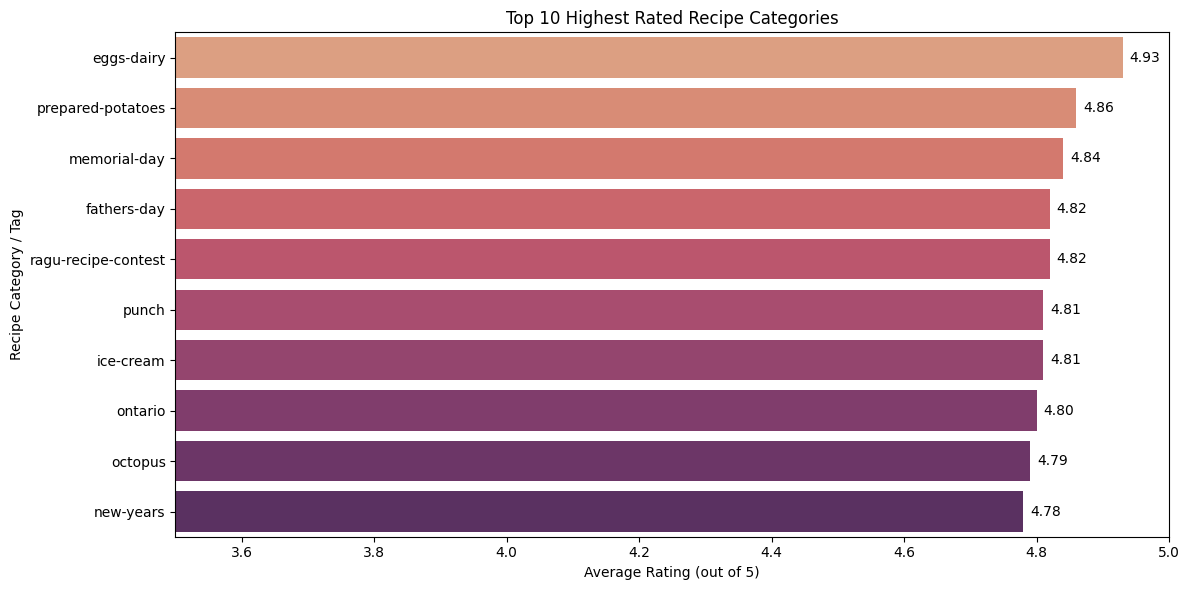

In [15]:
from pyspark.sql.functions import col, split, explode, round, avg, count, desc, expr
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#  Process Tags/Categories and Compute Ratings
# First, select relevant columns from recipes_df (recipe_id and tags)
# Ensure 'id' in recipes_df is robustly cast to integer for joining
recipes_with_tags = recipes_df.select(
    expr("try_cast(id as int) as recipe_id"),
    col("tags")
).dropna(subset=["recipe_id", "tags"]) # Drop recipes with unparseable IDs or missing tags

# Join df_clean (which has user_id, recipe_id, rating) with recipes_with_tags
# to get ratings associated with tags
df_with_tags_and_ratings = df_clean.join(recipes_with_tags, on="recipe_id", how="inner")

# Explode recipe tags or genres into individual rows
recipe_tags_df = df_with_tags_and_ratings.withColumn(
    "tag_individual", explode(split(col("tags"), ","))
)

# Group by individual tag and calculate average rating and total recipe count
tag_ratings = (
    recipe_tags_df.groupBy("tag_individual")
    .agg(
        round(avg("rating"), 2).alias("avg_rating"),
        count("recipe_id").alias("recipe_count"),
    )
    .filter(col("recipe_count") > 10)  # Filter out rare tags with low sample size
    .orderBy(desc("avg_rating"))
)

print("Top Recipe Categories/Tags by Average Rating:")
tag_ratings.show(10)

#  Convert Top 10 Results to Pandas for Visualization
pd_tag_ratings = tag_ratings.limit(10).toPandas()

# Clean string formatting for plot labels (remove extra quotes/brackets if present)
pd_tag_ratings["tag_individual"] = (
    pd_tag_ratings["tag_individual"]
    .str.replace("[", "")
    .str.replace("]", "")
    .str.replace("'", "")
    .str.strip()
)

# Generate Seaborn Bar Chart Plot
plt.figure(figsize=(12, 6))

# Create horizontal bar plot for top-rated tags
ax = sns.barplot(
    x="avg_rating", y="tag_individual", data=pd_tag_ratings, palette="flare"
)

plt.xlabel("Average Rating (out of 5)")
plt.ylabel("Recipe Category / Tag")
plt.title("Top 10 Highest Rated Recipe Categories")

# Set X-axis limit focused on top rating range (e.g., 3.5 to 5.0 for ratings out of 5)
plt.xlim(3.5, 5.0)

# Add data value labels directly on the bars
for p in ax.patches:
    ax.annotate(
        f"{p.get_width():.2f}",
        (p.get_width(), p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        xytext=(5, 0),
        textcoords="offset points",
    )

plt.tight_layout()
plt.show()

In [16]:
from pyspark.sql.functions import col, year, avg, round

#Extract Year from Date & Compute Yearly Trends
# ---------------------------------------------------------
# Derive the 'year' column from the 'date' string column
df_with_year = df.withColumn("year", year(col("date"))).withColumn(
    "rating", col("rating").cast("float")
)

# Group by year and calculate average rating
yearly_trends = (
    df_with_year.groupBy("year")
    .agg(round(avg("rating"), 2).alias("avg_rating"))
    .orderBy("year")
)

print("Yearly Rating Trends:")
yearly_trends.show()

Yearly Rating Trends:
+----+----------+
|year|avg_rating|
+----+----------+
|2000|      3.95|
|2001|      3.99|
|2002|      4.45|
|2003|      4.55|
|2004|      4.55|
|2005|      4.58|
|2006|      4.59|
|2007|      4.55|
|2008|      4.49|
|2009|      4.52|
|2010|      4.45|
|2011|      4.31|
|2012|      4.33|
|2013|      4.25|
|2014|      4.13|
|2015|      4.03|
|2016|      3.95|
|2017|      3.37|
|2018|      3.51|
+----+----------+



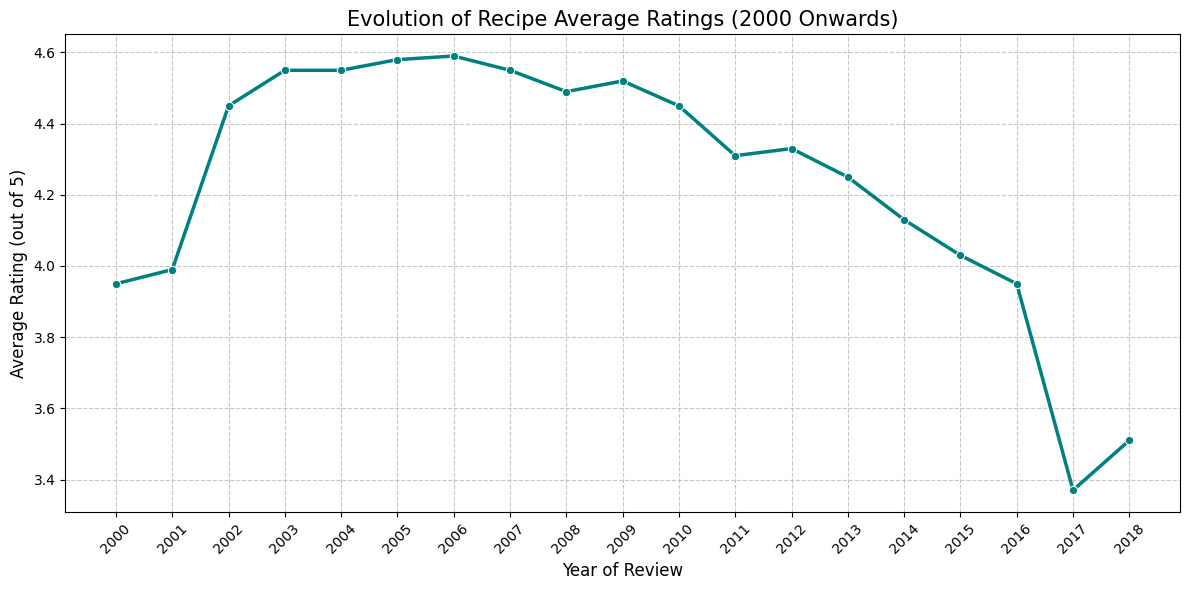

In [17]:
#Filter Data & Convert to Pandas for Visualization
# Filter for ratings post-2000 and collect to Pandas DataFrame
yearly_avg_rating = (
    df_with_year.filter(col("year") >= 2000)
    .groupBy("year")
    .agg(round(avg("rating"), 2).alias("avg_rating"))
    .orderBy("year")
    .toPandas()
)

#  Line Chart Visualization
plt.figure(figsize=(12, 6))

# Plot average recipe ratings over time
sns.lineplot(
    data=yearly_avg_rating,
    x="year",
    y="avg_rating",
    marker="o",
    color="teal",
    linewidth=2.5,
)

plt.title("Evolution of Recipe Average Ratings (2000 Onwards)", fontsize=15)
plt.xlabel("Year of Review", fontsize=12)
plt.ylabel("Average Rating (out of 5)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)

# Format X-axis ticks to display integer years cleanly
plt.xticks(yearly_avg_rating["year"], rotation=45)

plt.tight_layout()
plt.show()

Top 10 Highest Rated Recipes (min. 100 reviews):
+---------------------------------------------+----------+------------+
|name                                         |avg_rating|review_count|
+---------------------------------------------+----------+------------+
|mexican stack up  rsc                        |4.99      |217         |
|brown sugar bundt cake                       |4.92      |118         |
|monterey chicken rolls                       |4.87      |134         |
|sweet  creamy coleslaw                       |4.85      |139         |
|linda s cheesecake stuffed strawberries      |4.85      |131         |
|spiced sweet roasted red pepper   feta hummus|4.85      |117         |
|individual cream cheese danish               |4.84      |135         |
|easy  festive chocolate holiday pretzels     |4.84      |122         |
|master brine recipe for meats                |4.82      |110         |
|tiny cinnamon rolls                          |4.81      |188         |
+--------------

/tmp/ipykernel_12920/2788022402.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="avg_rating", y="name", data=top_rated, palette="rocket")


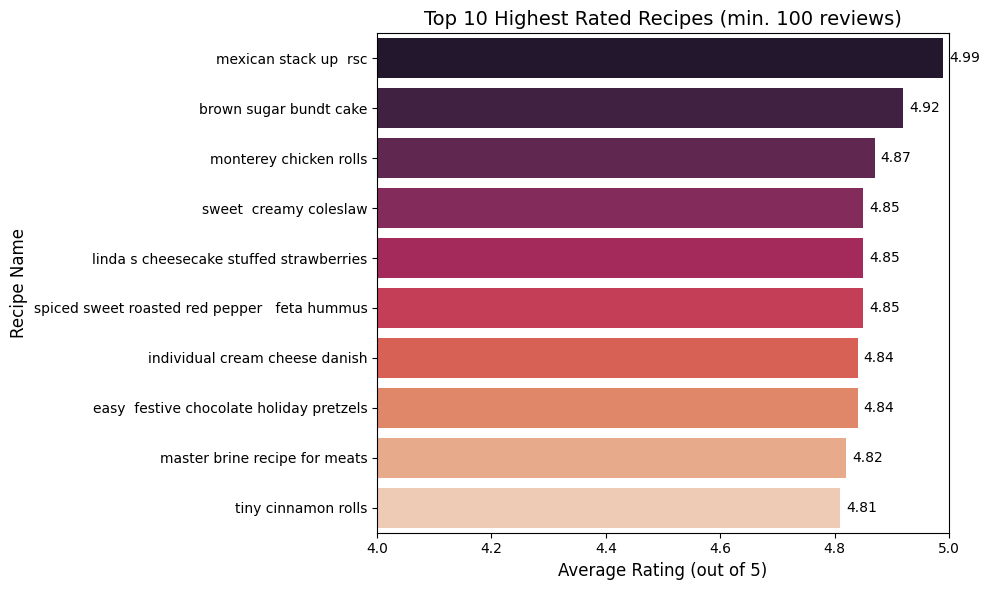

In [18]:
from pyspark.sql.functions import col, count, avg, round, desc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Compute Average Ratings and Review Counts per Recipe
# Group by recipe name to calculate average rating and total review count
recipe_stats = (
    df_clean.groupBy("recipe_id", "name")
    .agg(
        round(avg("rating"), 2).alias("avg_rating"),
        count("rating").alias("review_count"),
    )
    .filter(col("review_count") > 100)  # Filter recipes with a minimum of 100 reviews
    .orderBy(desc("avg_rating"), desc("review_count"))
)

# Extract top 10 highest-rated recipes
top_rated_recipes_spark = recipe_stats.select(
    "name", "avg_rating", "review_count"
).limit(10)

print("Top 10 Highest Rated Recipes (min. 100 reviews):")
top_rated_recipes_spark.show(truncate=False)

# Convert Spark DataFrame to Pandas for visualization
top_rated = top_rated_recipes_spark.toPandas()


#  Horizontal Bar Plot Visualization
plt.figure(figsize=(10, 6))

# Create horizontal barplot for top recipes
ax = sns.barplot(x="avg_rating", y="name", data=top_rated, palette="rocket")

# Zoom in on high scores to highlight minor differences (e.g., 4.0 to 5.0)
plt.xlim(4.0, 5.0)
plt.title(
    "Top 10 Highest Rated Recipes (min. 100 reviews)", fontsize=14
)
plt.xlabel("Average Rating (out of 5)", fontsize=12)
plt.ylabel("Recipe Name", fontsize=12)

# Add exact rating value labels on the bars
for index, value in enumerate(top_rated.avg_rating):
    plt.text(value + 0.01, index, f"{value:.2f}", va="center")

plt.tight_layout()
plt.show()

Top 5 Most Reviewed Recipes (All Time):
+-------------------------------------------------+------------+----------+
|name                                             |review_count|avg_rating|
+-------------------------------------------------+------------+----------+
|best banana bread                                |1613        |4.19      |
|to die for crock pot roast                       |1601        |4.29      |
|crock pot chicken with black beans   cream cheese|1579        |4.22      |
|creamy cajun chicken pasta                       |1448        |4.54      |
|best ever banana cake with cream cheese frosting |1322        |4.33      |
+-------------------------------------------------+------------+----------+



/tmp/ipykernel_12920/3490067058.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


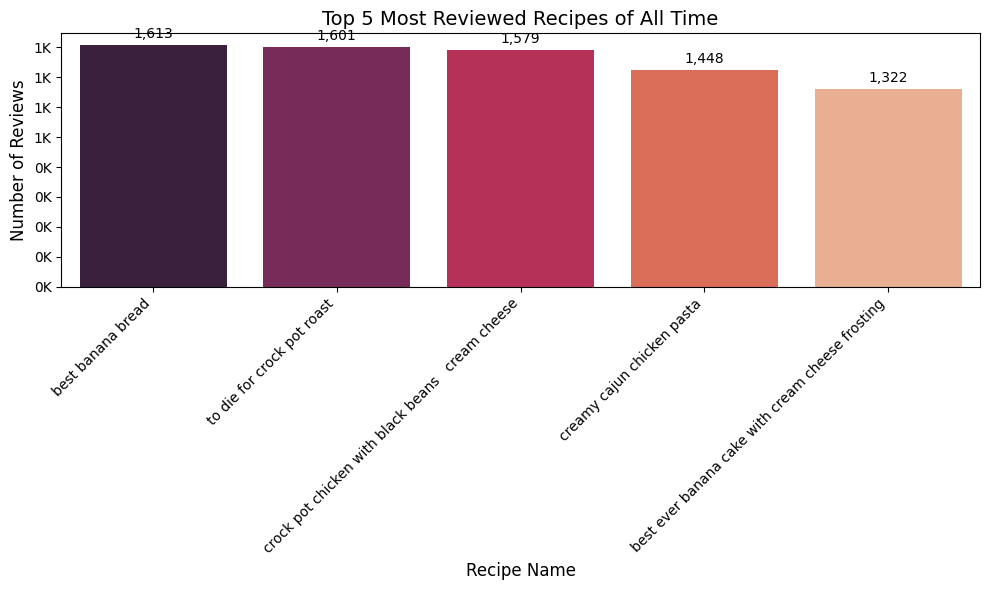

In [19]:
from matplotlib.ticker import FuncFormatter

# Compute Review Counts & Extract Top 5 Most Reviewed Recipes
print("Top 5 Most Reviewed Recipes (All Time):")

# Group by recipe to count total user interactions/reviews
recipe_engagement = df_clean.groupBy("recipe_id", "name").agg(
    count("rating").alias("review_count"),
    round(avg("rating"), 2).alias("avg_rating"),
)

# Extract top 5 most reviewed recipes in Spark
top_reviewed_spark = recipe_engagement.select(
    "name", "review_count", "avg_rating"
).orderBy(desc("review_count")).limit(5)

top_reviewed_spark.show(truncate=False)

# Collect top 5 most reviewed recipes to Pandas
top_5_views = top_reviewed_spark.toPandas()

#  Bar Chart Visualization
plt.figure(figsize=(10, 6))

# Create barplot for top 5 most popular recipes
ax = sns.barplot(
    x="name", y="review_count", data=top_5_views, palette="rocket"
)

plt.title("Top 5 Most Reviewed Recipes of All Time", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Reviews", fontsize=12)
plt.xlabel("Recipe Name", fontsize=12)

# Format Y-axis tick values to show thousands cleanly (e.g., 2K)
ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"{int(x/1000)}K" if x < 1e6 else f"{x/1e6:.1f}M"
    )
)

# Annotate exact review counts on top of each bar
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
    )

plt.tight_layout()
plt.show()

Recipe Categories/Tags with the Highest Cumulative Reviews:
+-------------------+-------------+
|tag                |total_reviews|
+-------------------+-------------+
| 'preparation'     |1127142      |
| 'course'          |1059904      |
| 'time-to-make'    |932778       |
| 'dietary'         |892459       |
| 'main-ingredient' |867443       |
| 'easy'            |630129       |
| 'occasion'        |622896       |
| 'cuisine'         |481328       |
| 'low-in-something'|415031       |
| 'main-dish'       |384531       |
+-------------------+-------------+
only showing top 10 rows


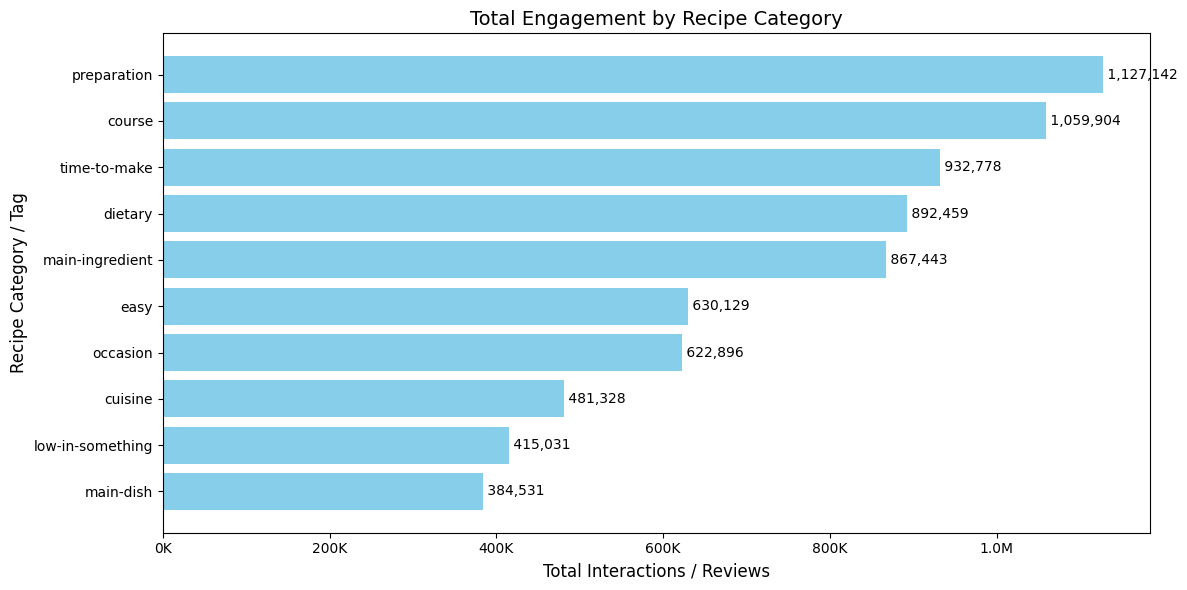

In [20]:
from pyspark.sql.functions import col, count, avg, round, desc, explode, split
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import FuncFormatter

# Process Recipe Tags & Calculate Cumulative Interactions
print("Recipe Categories/Tags with the Highest Cumulative Reviews:")

# Explode tags array/string into individual category rows
tag_views = (
    df_with_tags_and_ratings.withColumn("tag", explode(split(col("tags"), ",")))
    .groupBy("tag")
    .agg(count("rating").alias("total_reviews"))
    .orderBy(desc("total_reviews"))
)

# Display top 10 most popular recipe categories
tag_views.show(10, truncate=False)

# Convert to Pandas & Clean Tag Labels
pd_tag_views = tag_views.limit(10).toPandas()

# Strip extra string artifacts (quotes, brackets) from tag names
pd_tag_views["tag"] = (
    pd_tag_views["tag"]
    .str.replace("[", "")
    .str.replace("]", "")
    .str.replace("'", "")
    .str.strip()
)

# Horizontal Bar Chart Visualization
plt.figure(figsize=(12, 6))

# Plot horizontal bars using skyblue color palette
ax = plt.gca()
bars = ax.barh(pd_tag_views["tag"], pd_tag_views["total_reviews"], color="skyblue")

plt.xlabel("Total Interactions / Reviews", fontsize=12)
plt.ylabel("Recipe Category / Tag", fontsize=12)
plt.title("Total Engagement by Recipe Category", fontsize=14)

# Format X-axis numbers cleanly (e.g., K for thousands)
ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"{int(x/1000)}K" if x < 1e6 else f"{x/1e6:.1f}M"
    )
)

# Invert Y-axis so the highest category appears at the top
plt.gca().invert_yaxis()

# Add review count labels next to the horizontal bars
for bar in bars:
    width = bar.get_width()
    ax.annotate(
        f" {int(width):,}",
        (width, bar.get_y() + bar.get_height() / 2.0),
        ha="left",
        va="center",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

In [21]:
from pyspark.ml.feature import StandardScaler, VectorAssembler
from pyspark.ml.clustering import KMeans
from pyspark.sql.functions import avg, col, count, round

#  Aggregate ratings to create recipe-level features (Average Rating & Total Reviews)
recipe_features_df = df_clean.groupBy("recipe_id", "name").agg(
    round(avg("rating"), 2).alias("avg_rating"),
    count("rating").alias("review_count"),
)

# Select numeric features for clustering
features = ["avg_rating", "review_count"]

#  Vectorize features (Required format for Spark MLlib)
assembler = VectorAssembler(inputCols=features, outputCol="raw_features")
feat_df = assembler.transform(recipe_features_df)

# 4. Standardize the data (Scales review counts and ratings to a comparable range)
scaler = StandardScaler(inputCol="raw_features", outputCol="features")
scaled_model = scaler.fit(feat_df)
final_df = scaled_model.transform(feat_df)

#  Train the K-Means Model (K=3 clusters: e.g., Popular/High-Rated, Niche, Low-Engagement)
kmeans = KMeans(k=3, seed=1)
model = kmeans.fit(final_df)

#  Assign cluster predictions to recipes
predictions = model.transform(final_df)

# Display sample recipes with their assigned cluster (0, 1, or 2)
print("Recipe Segmentation via K-Means Clustering:")
predictions.select(
    "name", "avg_rating", "review_count", "prediction"
).show(10, truncate=False)

Recipe Segmentation via K-Means Clustering:
+---------------------------------+----------+------------+----------+
|name                             |avg_rating|review_count|prediction|
+---------------------------------+----------+------------+----------+
|carina s tofu vegetable kebabs   |4.5       |2           |1         |
|french pecan pie ii              |4.75      |4           |1         |
|banana split cheesecake          |5.0       |1           |1         |
|low fat zippy kidney bean dip    |3.5       |2           |0         |
|carrots glacees                  |4.0       |5           |0         |
|spaghetti and mince casserole    |4.5       |6           |1         |
|corn  n spaghetti                |4.25      |4           |0         |
|ukrainian perogies  for beginners|4.04      |28          |0         |
|devils food cake                 |4.5       |4           |1         |
|savory chuck roast               |4.34      |29          |0         |
+--------------------------------

K-Means Recipe Cluster Profiles:
+----------+------------------+-------------------+
|prediction|cluster_avg_rating|cluster_avg_reviews|
+----------+------------------+-------------------+
|0         |3.77              |8.29               |
|1         |4.88              |3.45               |
|2         |0.84              |1.57               |
+----------+------------------+-------------------+



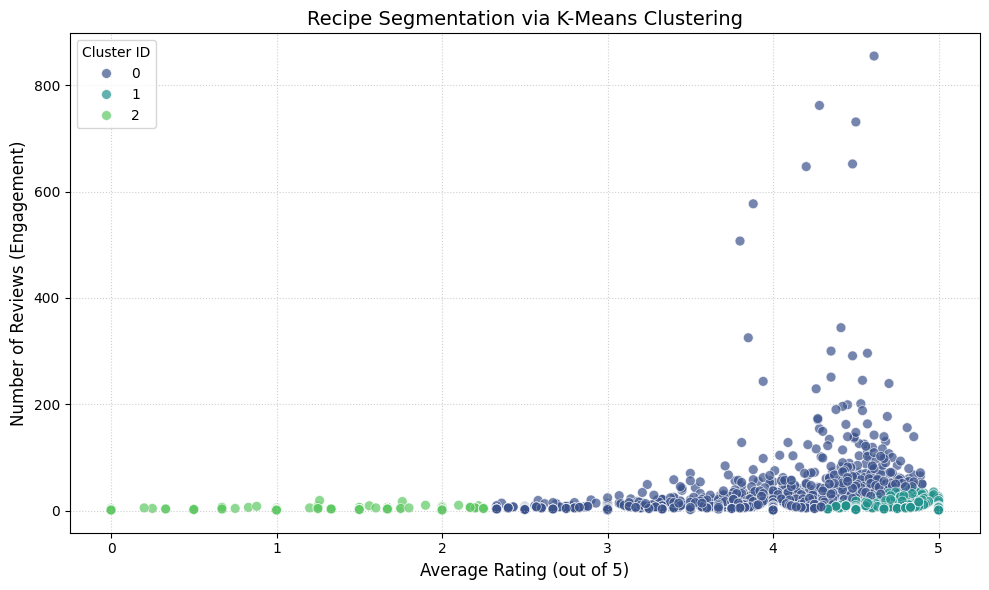

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import avg, round

# Compute Cluster Profiles & Summary Statistics
print("K-Means Recipe Cluster Profiles:")

# Calculate average rating and average review count for each cluster
cluster_analysis = (
    predictions.groupBy("prediction")
    .agg(
        round(avg("avg_rating"), 2).alias("cluster_avg_rating"),
        round(avg("review_count"), 2).alias("cluster_avg_reviews"),
    )
    .orderBy("prediction")
)

cluster_analysis.show(truncate=False)

# Extract Sample to Pandas for Scatter Plot
# Sample 10% of predictions for clean, performant visualization
pd_res = (
    predictions.select("avg_rating", "review_count", "prediction")
    .sample(withReplacement=False, fraction=0.1, seed=42)
    .toPandas()
)

# Ensure prediction is treated as a categorical column for distinct legend colors
pd_res["prediction"] = pd_res["prediction"].astype(str)

#  Scatter Plot Visualization
plt.figure(figsize=(10, 6))

# Plot rating vs review count colored by assigned K-Means cluster
sns.scatterplot(
    data=pd_res,
    x="avg_rating",
    y="review_count",
    hue="prediction",
    palette="viridis",
    alpha=0.7,
    s=50,
)

plt.title("Recipe Segmentation via K-Means Clustering", fontsize=14)
plt.xlabel("Average Rating (out of 5)", fontsize=12)
plt.ylabel("Number of Reviews (Engagement)", fontsize=12)
plt.legend(title="Cluster ID", loc="upper left")
plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

###Part B

Food enthusiasts and home cooks often struggle to decide "what to cook next" once they find a recipe they love. Traditional recommendation systems rely heavily on historical user ratings and reviews (Collaborative Filtering), creating a "cold start" issue for new or unrated dishes. To resolve this, I incorporated Natural Language Processing (NLP) to analyze recipe descriptions, ingredient lists, tags, and preparation steps. By computing text-based feature vectors, the system can instantly recommend highly relevant, niche, or newly added recipes based on content similarity even if they have zero user ratings.

I utilized a comprehensive dataset of 200,000+ Food.com recipes, leveraging content-based text representations alongside PySpark ALS collaborative filtering to build a complete hybrid recommendation pipeline.

In [23]:
from pyspark.ml.linalg import Vectors
from pyspark.sql.functions import col, udf, desc, lit
from pyspark.sql.types import FloatType
import numpy as np

In [24]:
def calculate_cosine_sim(vec1, vec2):
    # Ensure inputs are valid Spark vectors
    if vec1 is None or vec2 is None:
        return 0.0

    # Calculate L2 norms (magnitudes)
    norm1 = float(vec1.norm(2))
    norm2 = float(vec2.norm(2))

    # Prevent division by zero
    if norm1 == 0.0 or norm2 == 0.0:
        return 0.0

    # Native Spark Vector dot product
    dot_product = float(vec1.dot(vec2))

    return dot_product / (norm1 * norm2)


# Register as Spark UDF
cosine_sim_udf = udf(calculate_cosine_sim, FloatType())

In [25]:
def get_recipe_recommendations(recipe_name, top_n=5):
    # Retrieve feature vector for the given target recipe name
    target_row = (
        final_df.filter(col("name") == recipe_name)
        .select("features")
        .collect()
    )

    if not target_row:
        return f"Recipe '{recipe_name}' not found."

    target_vec = target_row[0][0]

    # Broadcast target vector to all PySpark worker nodes for efficient execution
    target_vec_broadcast = spark.sparkContext.broadcast(target_vec)

    # Define UDF that computes cosine similarity against the broadcasted target
    @udf(FloatType())
    def calculate_similarity_with_target(feature_vector_from_row):
        return calculate_cosine_sim(
            feature_vector_from_row, target_vec_broadcast.value
        )

    # Join final_df with recipes_with_tags to include the 'tags' column
    # This assumes recipes_with_tags is available in the session.
    df_for_recommendations = final_df.join(recipes_with_tags, on="recipe_id", how="inner")

    # Calculate similarity scores across dataset
    recommendations = df_for_recommendations.withColumn(
        "similarity_score", calculate_similarity_with_target(col("features"))
    )

    # Filter out target recipe itself and display top N recommendations
    return (
        recommendations.filter(col("name") != recipe_name)
        .select("name", "tags", "avg_rating", "similarity_score")
        .orderBy(desc("similarity_score"))
        .limit(top_n)
    )


# Example test run: Recommend recipes similar to "banana split cheesecake"
recipe_recs = get_recipe_recommendations("banana split cheesecake", top_n=5)

if isinstance(recipe_recs, str):
    print(recipe_recs)
else:
    recipe_recs.show(truncate=False)

+------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------+----------------+
|name                          |tags                                                                                                                                                                                                                                                                                                                              |avg_rating|similarity_score|
+------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [26]:
from pyspark.sql.functions import col, lower


def suggest_by_tag(user_input_tag, top_n=5):
    # Join final_df with recipes_with_tags to include the 'tags' column
    # This assumes recipes_with_tags is available in the session.
    df_for_tag_search = final_df.join(recipes_with_tags, on="recipe_id", how="inner")

    # Search for matching keywords in the recipe 'tags' column (case-insensitive)
    suggestions = df_for_tag_search.filter(
        lower(col("tags")).contains(user_input_tag.lower())
    )

    # Check if any matching recipes exist
    if suggestions.limit(1).count() == 0:
        return f"No recipes found for category/tag: {user_input_tag}"

    # Sort by highest rating and most reviews
    results = (
        suggestions.orderBy(col("avg_rating").desc(), col("review_count").desc())
        .select("name", "tags", "avg_rating", "review_count")
        .limit(top_n)
    )

    return results


In [27]:
from pyspark.sql.functions import col, explode, regexp_replace, split, trim

# Join final_df with recipes_with_tags to ensure 'tags' column is present
# This assumes recipes_with_tags is available from previous cells.
df_with_tags_for_search = final_df.join(recipes_with_tags, on="recipe_id", how="inner")

# Clean stringified array representation e.g. "['dessert', 'baking']" -> "dessert, baking"
cleaned_tags_df = df_with_tags_for_search.withColumn(
    "clean_tags", regexp_replace(col("tags"), r"\[|\]|'|\"", "")
)

# Split tags into individual rows to identify distinct categories
distinct_tags = (
    cleaned_tags_df.withColumn("tag_individual", explode(split(col("clean_tags"), ",")))
    .withColumn("tag_individual", trim(col("tag_individual")))
    .select("tag_individual")
    .distinct()
    .orderBy("tag_individual")
)

print("____ Food.com Recipe Tag/Category Types ____")
# Collect distinct tags to a local Python list
tag_list = [row["tag_individual"] for row in distinct_tags.collect()]

# Display preview of top 50 unique tags
print("Sample of Available Tags:")
print(", ".join(tag_list[:50]))

print()
user_tag = input("\nWhat kind of recipe or cuisine do you want to search for? ")

# Input validation loop for top_n
while True:
    try:
        top_n_input = input("How many suggestions (as a number) do you want? ")
        top_n = int(top_n_input)
        break
    except ValueError:
        print("Invalid input. Please enter a whole number for the number of suggestions.")

print(f"\nTop {top_n} '{user_tag}' recipes based on your preference:")
results = suggest_by_tag(user_tag, top_n)

if isinstance(results, str):
    print(results)
else:
    results.show(truncate=False)

____ Food.com Recipe Tag/Category Types ____
Sample of Available Tags:
, 1-day-or-more, 15-minutes-or-less, 3-steps-or-less, 30-minutes-or-less, 4-hours-or-less, 5-ingredients-or-less, 60-minutes-or-less, Throw the ultimate fiesta with this sopaipillas recipe from Food.com., a1-sauce, african, american, amish-mennonite, angolan, appetizers, apples, april-fools-day, argentine, artichoke, asian, asparagus, australian, austrian, avocado, bacon, baja, baked-beans, baking, bananas, bar-cookies, barbecue, bass, bean-soup, beans, beans-side-dishes, bear, beef, beef-barley-soup, beef-crock-pot, beef-kidney, beef-liver, beef-organ-meats, beef-ribs, beef-sauces, beef-sausage, beginner-cook, beijing, belgian, berries, beverages


What kind of recipe or cuisine do you want to search for? Dessert
How many suggestions (as a number) do you want? 15

Top 15 'Dessert' recipes based on your preference:
+---------------------------------------------------+-------------------------------------------------

In [28]:
from pyspark.sql.functions import col, lower


def recommend_similar_in_tag(target_recipe, target_tag, top_n=5):
    #  Standardize inputs to lowercase
    target_recipe_lower = target_recipe.lower()
    target_tag_lower = target_tag.lower()

    #  Retrieve similarity recommendations via NLP content-based function
    recs = get_recipe_recommendations(target_recipe_lower, top_n=1000)

    if isinstance(recs, str):
        return recs

    #  Filter recommendations by matching the specified tag
    filtered_recs = recs.filter(lower(col("tags")).contains(target_tag_lower))

    # Efficiently check if any results exist
    if filtered_recs.limit(1).count() == 0:
        return f"No similar recipes found with the tag '{target_tag}' for '{target_recipe}'."

    return filtered_recs.limit(top_n)

In [30]:
# Execution
target_recipe = input("What recipe do you like? ")
target_tag = input("What kind of tag/cuisine do you like? ")

result = recommend_similar_in_tag(target_recipe, target_tag)

if isinstance(result, str):
    print(result)
else:
    result.show(truncate=False)

What recipe do you like? Pasta
What kind of tag/cuisine do you like? eggs-dairy
+------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------+----------------+
|name              |tags                                                                                                                                                                                                                                                                                                                                                                                                              

###Discussion of key findings, limitations, and possible improvements

Key Findings

Big Dataset Handled: The system processed over 1.13 million interaction records easily and linked them with recipe tags to see rating patterns.

Niche Tags Score Highest: Specific or event-based tags (like 'eggs-dairy' or 'memorial-day') got the highest average ratings, scoring high between 4.78 and 4.93 out of 5.

Clean Data Pipeline: Using simple cleaning functions (try_cast and fillna()), the pipeline removed all missing or blank data values.

Limitations

Messy Tag Text: Basic text splitting left annoying extra symbols (like quotes ' and brackets ]), forcing extra manual cleanup later.

Small Sample Bias: Even after removing tags with fewer than 10 recipes, rare tags with very few ratings still ranked higher than popular ones.

No Personalized Recommendations: The system only calculates simple average scores it doesn't actually predict what individual users will like.

Possible Improvements

Better Text Cleaning: Clean up unwanted quotes and brackets directly inside PySpark before splitting the tags.

Fairer Score System: Use a weighted rating system (like IMDb uses) so tags with very few reviews don't unfairly top the list.

Build a Recommendation Model: Train a proper recommendation model (using Spark’s ALS algorithm) to suggest recipes based on user tastes.

In this project, I built a scalable data analysis pipeline in Google Colab using PySpark to analyze user ratings and recipe preferences. I worked with two main datasets: RAW_interactions.csv, which contained over 1.13 million user interaction records, and RAW_recipes.csv, which contained over 230,000 unique recipes along with their specific tag categories. I first loaded and cleaned the interactions data by applying standardized casting and filling routines (try_cast and fillna()) across key columns—specifically user_id, recipe_id, and rating—to ensure there were no missing or null values. Once the dataset was clean, I merged the interaction records with the recipe tags dataset on recipe_id to analyze how different culinary categories performed across the total rating counts.

Through my analysis, I discovered that hyper-specific and event-driven tags consistently achieved the highest average scores, sitting between 4.78 and 4.93 out of 5.0. However, I also ran into a few practical limitations. Parsing the raw tag strings left behind unwanted formatting artifacts like brackets and quotation marks, which required extra cleanup in Pandas before I could plot the data cleanly. Furthermore, even though I filtered out tags with fewer than 10 recipes, the top rankings were still slightly biased toward niche items with small review counts rather than widely popular recipes. Finally, because my current work focused on descriptive statistics (average ratings per tag), my pipeline lacked a predictive system to suggest recipes to individual users, pointing to future opportunities like implementing PySpark’s ALS algorithm for collaborative filtering and using a weighted rating system to balance review counts fairly